# Лабораторная работа №1

**Тема:** Базовые методы анализа данных и машинного обучения  
**Студент:** Салех Али 01  
**Дисциплина:** Эргатические системы

## Цель работы

Целью лабораторной работы является знакомство с базовыми понятиями машинного обучения, визуальным анализом данных, бинарной классификацией с помощью логистической регрессии, а также демонстрация явления переобучения на примере линейной регрессии.

В работе используется датасет Iris. Дополнительно рассматривается влияние сложности модели на качество аппроксимации и обобщающую способность.

## 1. Импорт необходимых библиотек

На данном этапе подключаются библиотеки для обработки данных, визуализации и построения моделей машинного обучения.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, mean_squared_error
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

## 2. Загрузка датасета Iris

В качестве исходных данных используется датасет Iris.  
Файл `iris.data` содержит 4 числовых признака и 1 категориальный признак — название класса растения.

Так как в файле отсутствуют названия столбцов, они задаются вручную.

In [7]:
columns = [
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width",
    "class"
]

DATA_PATH = "/kaggle/input/datasets/abokarim/iris-data-salehali/iris.data"

df = pd.read_csv(DATA_PATH, header=None, names=columns)
df = df.dropna()

df.head()

,sepal_length,sepal_width,petal_length,petal_width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


## 3. Первичный анализ датасета

На данном этапе выполняется предварительный анализ данных:
- определяется размер таблицы;
- проверяется структура признаков;
- анализируется распределение классов;
- рассчитываются базовые статистические характеристики.

In [8]:
print("Размер датасета:", df.shape)
print("\nНазвания столбцов:")
print(df.columns)

print("\nИнформация о данных:")
print(df.info())

print("\nРаспределение классов:")
print(df["class"].value_counts())

Размер датасета: (150, 5)

Названия столбцов:
Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'class'], dtype='object')

Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   class         150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None

Распределение классов:
class
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


Ниже приведены описательные статистики для числовых признаков датасета.

In [9]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


## 4. Визуальный анализ данных с помощью pairplot

Для визуального исследования структуры датасета строится матрица попарных диаграмм рассеяния (`pairplot`).  
Это позволяет оценить:
- степень разделимости классов;
- взаимосвязь между признаками;
- наличие пересечений между классами.

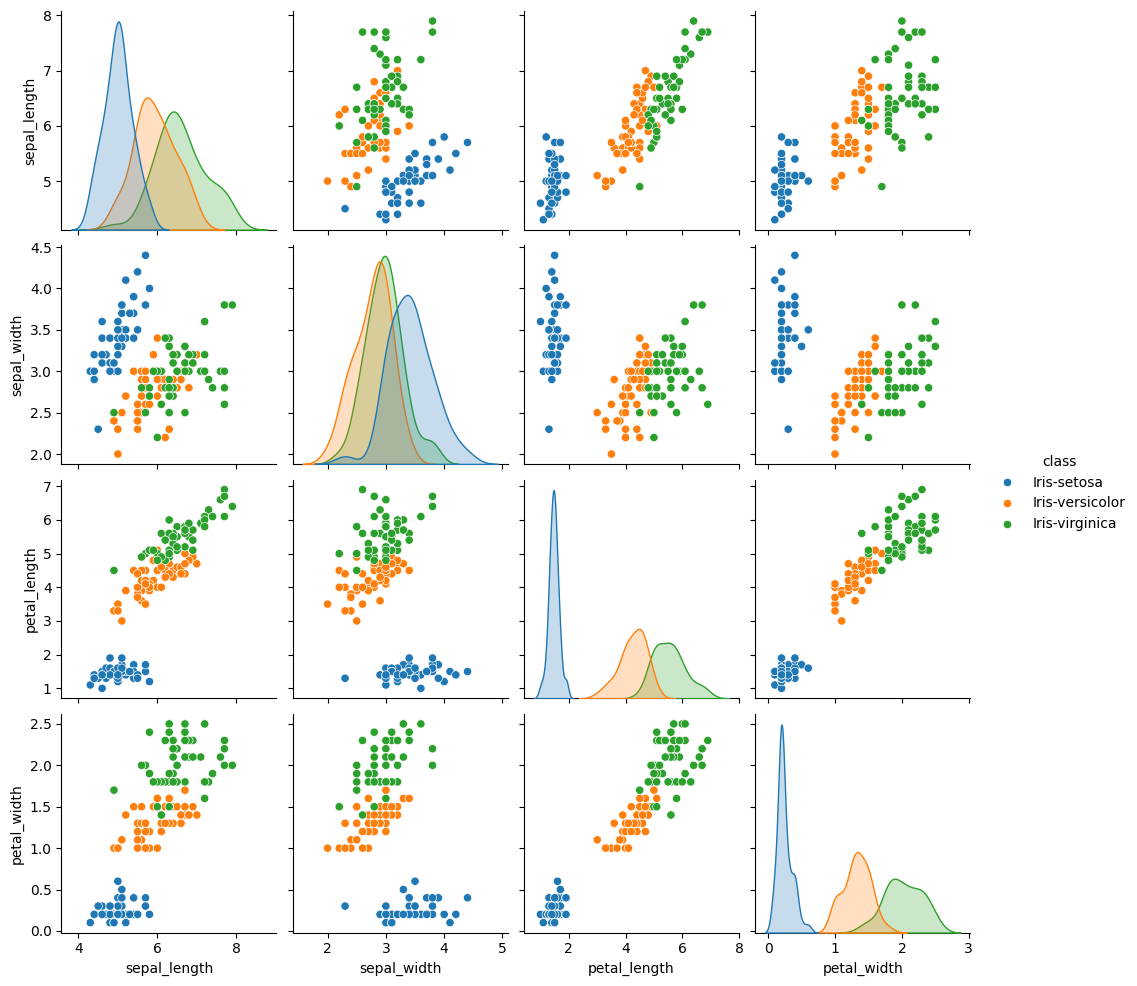

In [10]:
sns.pairplot(df, hue="class")
plt.show()

По полученным графикам можно сделать вывод, что класс `Iris-setosa` достаточно хорошо отделяется от остальных классов по нескольким признакам.  
Классы `Iris-versicolor` и `Iris-virginica` имеют более заметное пересечение, что делает задачу их разделения более сложной.

## 5. Подготовка данных для бинарной классификации

Согласно условию задания 1, необходимо построить модель логистической регрессии для бинарной классификации.  
Для этого из исходного датасета выбираются два класса:
- `Iris-setosa`
- `Iris-versicolor`

Далее классы кодируются числами:
- `0` — `Iris-setosa`
- `1` — `Iris-versicolor`

In [11]:
binary_df = df[df["class"].isin(["Iris-setosa", "Iris-versicolor"])].copy()

binary_df["target"] = binary_df["class"].map({
    "Iris-setosa": 0,
    "Iris-versicolor": 1
})

binary_df.head()

,sepal_length,sepal_width,petal_length,petal_width,class,target
0,5.1,3.5,1.4,0.2,Iris-setosa,0
1,4.9,3.0,1.4,0.2,Iris-setosa,0
2,4.7,3.2,1.3,0.2,Iris-setosa,0
3,4.6,3.1,1.5,0.2,Iris-setosa,0
4,5.0,3.6,1.4,0.2,Iris-setosa,0


In [12]:
X = binary_df[["sepal_length", "sepal_width", "petal_length", "petal_width"]]
y = binary_df["target"]

print("Размер матрицы признаков:", X.shape)
print("Размер вектора ответов:", y.shape)
print("Уникальные классы:", y.unique())

Размер матрицы признаков: (100, 4)
Размер вектора ответов: (100,)
Уникальные классы: [0 1]


## 6. Разделение данных на обучающую и тестовую выборки

Для корректной оценки качества модели данные делятся на:
- обучающую выборку;
- тестовую выборку.

Это необходимо для проверки способности модели обобщать данные, а не просто запоминать обучающие примеры.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Размер обучающей выборки:", X_train.shape[0])
print("Размер тестовой выборки:", X_test.shape[0])

Размер обучающей выборки: 80
Размер тестовой выборки: 20


## 7. Построение модели логистической регрессии

Для решения задачи бинарной классификации используется модель логистической регрессии.  
После обучения модель применяется к тестовой выборке для получения предсказаний.

In [15]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)

## 8. Оценка качества модели

Для оценки качества классификации используются следующие метрики:
- accuracy;
- матрица ошибок;
- classification report.

In [16]:
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("Accuracy:", acc)
print("\nМатрица ошибок:")
print(cm)

print("\nClassification report:")
print(classification_report(y_test, y_pred))

Accuracy: 1.0

Матрица ошибок:
[[10  0]
 [ 0 10]]

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        10

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



Полученные результаты показывают, что модель логистической регрессии успешно разделяет два выбранных класса.  
Высокое значение accuracy свидетельствует о хорошей разделимости объектов в пространстве признаков.

Для более наглядного анализа результатов классификации построим тепловую карту матрицы ошибок.

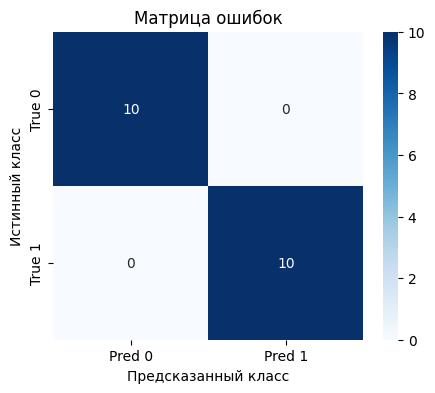

In [17]:
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred 0", "Pred 1"],
            yticklabels=["True 0", "True 1"])
plt.title("Матрица ошибок")
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.show()

## 9. Анализ коэффициентов логистической регрессии

Коэффициенты модели позволяют оценить вклад каждого признака в процесс классификации.

In [18]:
coef_df = pd.DataFrame({
    "Признак": X.columns,
    "Коэффициент": log_reg.coef_[0]
})

coef_df

,Признак,Коэффициент
0,sepal_length,0.539426
1,sepal_width,-0.790306
2,petal_length,2.185780
3,petal_width,0.913189


По значениям коэффициентов можно сделать вывод, какие признаки сильнее влияют на разделение классов.  
Знак коэффициента показывает направление влияния признака, а величина — относительную силу этого влияния.

## 10. Демонстрация переобучения на примере линейной регрессии

Для демонстрации переобучения будут сгенерированы искусственные данные с шумом.  
Далее будут построены модели различной сложности и выполнено сравнение качества на обучающей и тестовой выборках.

In [20]:
np.random.seed(42)

X = np.linspace(0, 1, 30)
y = np.sin(2 * np.pi * X) + np.random.normal(0, 0.2, size=X.shape)

X = X.reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

Ниже представлен график сгенерированных данных, разделённых на обучающую и тестовую выборки.

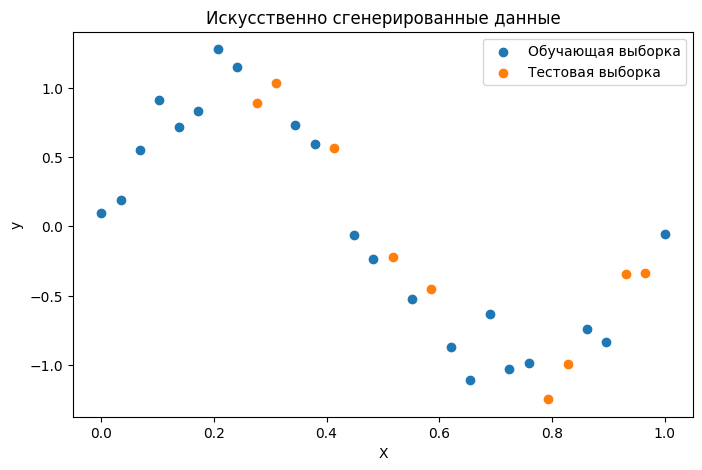

In [21]:
plt.figure(figsize=(8, 5))
plt.scatter(X_train, y_train, label="Обучающая выборка")
plt.scatter(X_test, y_test, label="Тестовая выборка")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Искусственно сгенерированные данные")
plt.legend()
plt.show()

## 11. Сравнение моделей различной сложности

Для демонстрации переобучения рассматриваются полиномиальные модели различных степеней:
- степень 1;
- степень 4;
- степень 15.

Для каждой модели вычисляется ошибка на обучающей и тестовой выборках.

In [22]:
degrees = [1, 4, 15]
results = []

for degree in degrees:
    model = make_pipeline(
        PolynomialFeatures(degree),
        LinearRegression()
    )
    
    model.fit(X_train, y_train)
    
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    
    results.append({
        "Степень полинома": degree,
        "Ошибка на обучающей выборке (MSE)": train_mse,
        "Ошибка на тестовой выборке (MSE)": test_mse
    })

results_df = pd.DataFrame(results)
results_df

,Степень полинома,Ошибка на обучающей выборке (MSE),Ошибка на тестовой выборке (MSE)
0,1,0.250523,0.267285
1,4,0.024854,0.033282
2,15,0.009915,205.237864


Если ошибка на обучающей выборке очень мала, а на тестовой существенно возрастает, это свидетельствует о переобучении модели.

Ожидается, что модель высокой степени будет слишком точно подстраиваться под шум в обучающих данных, из-за чего качество на новых данных ухудшится.

## 12. Графическое сравнение моделей

Сначала построим модель низкой сложности — полином первой степени.

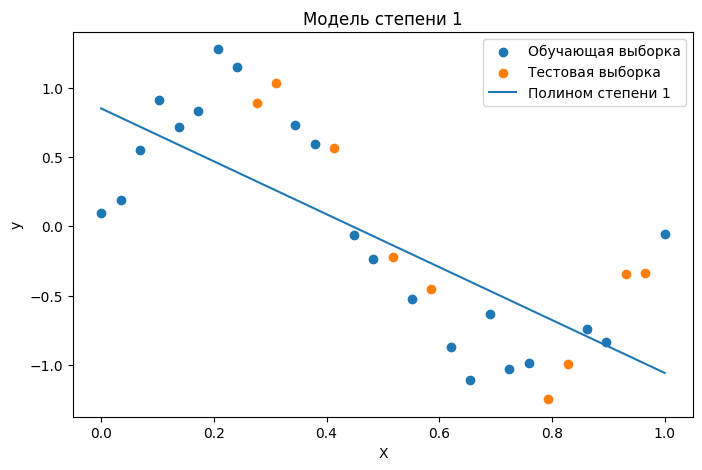

In [23]:
degree = 1
model = make_pipeline(
    PolynomialFeatures(degree),
    LinearRegression()
)
model.fit(X_train, y_train)

x_plot = np.linspace(0, 1, 300).reshape(-1, 1)
y_plot = model.predict(x_plot)

plt.figure(figsize=(8, 5))
plt.scatter(X_train, y_train, label="Обучающая выборка")
plt.scatter(X_test, y_test, label="Тестовая выборка")
plt.plot(x_plot, y_plot, label="Полином степени 1")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Модель степени 1")
plt.legend()
plt.show()

Теперь рассмотрим модель средней сложности.

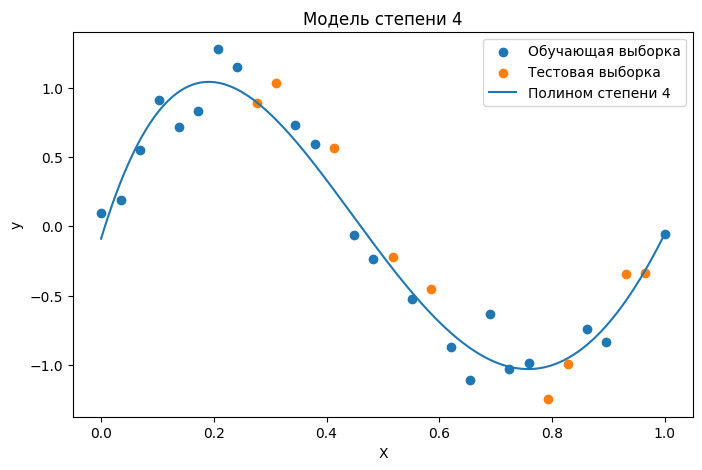

In [24]:
degree = 4
model = make_pipeline(
    PolynomialFeatures(degree),
    LinearRegression()
)
model.fit(X_train, y_train)

x_plot = np.linspace(0, 1, 300).reshape(-1, 1)
y_plot = model.predict(x_plot)

plt.figure(figsize=(8, 5))
plt.scatter(X_train, y_train, label="Обучающая выборка")
plt.scatter(X_test, y_test, label="Тестовая выборка")
plt.plot(x_plot, y_plot, label="Полином степени 4")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Модель степени 4")
plt.legend()
plt.show()

Наконец, рассмотрим модель очень высокой сложности.  
В этом случае можно наблюдать эффект переобучения.

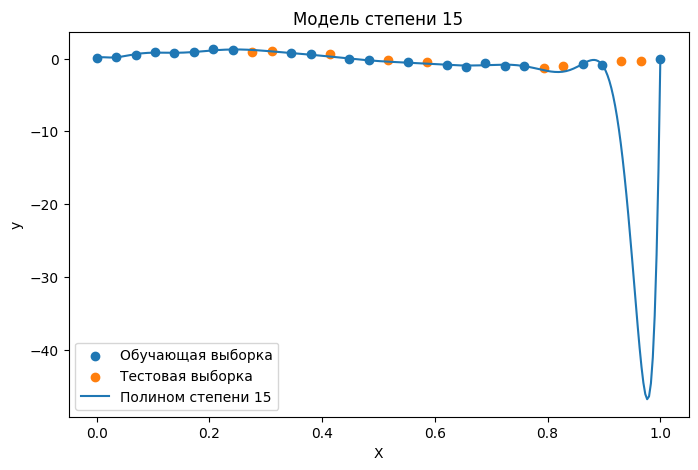

In [25]:
degree = 15
model = make_pipeline(
    PolynomialFeatures(degree),
    LinearRegression()
)
model.fit(X_train, y_train)

x_plot = np.linspace(0, 1, 300).reshape(-1, 1)
y_plot = model.predict(x_plot)

plt.figure(figsize=(8, 5))
plt.scatter(X_train, y_train, label="Обучающая выборка")
plt.scatter(X_test, y_test, label="Тестовая выборка")
plt.plot(x_plot, y_plot, label="Полином степени 15")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Модель степени 15")
plt.legend()
plt.show()

## Вывод

В ходе лабораторной работы был изучен датасет Iris, выполнен его первичный и визуальный анализ, а также решена задача бинарной классификации с помощью логистической регрессии.  
Модель показала высокое качество классификации на тестовой выборке.

Кроме того, на искусственно сгенерированных данных был продемонстрирован эффект переобучения на примере линейной регрессии с полиномиальными признаками.  
Было показано, что чрезмерное усложнение модели ухудшает её способность к обобщению.

Таким образом, в рамках работы были освоены базовые подходы к анализу данных, классификации и исследованию сложности моделей машинного обучения.